v1.0对本项目做了一点更新

1. 前置任务可参考新的车牌检测+矫正：https://aistudio.baidu.com/aistudio/projectdetail/6545272

2. 为车牌识别数据集加矫正，先对车牌进行矫正后再进行识别

3. 矫正后的数据集一定程度降低了任务难度，项目演示训练了40个epoch，就达到验证集98.4%的精度

4. 将模型与batch解耦，验证推理精度不受batch的影响

~~和车牌检测项目搭配：https://aistudio.baidu.com/aistudio/projectdetail/5557065~~


## 车牌识别
LPRNet端到端训练车牌识别

本项目包括

1. 完整训练推理过程
2. 模型转onnx以及onnx的检查和推理



### 数据集构建

In [1]:
# 数据解压
!unzip -o -q -d /home/aistudio/data /home/aistudio/data/data17968/CCPD2019.zip

In [2]:
"""
CCPD数据集的图片名称即是label:
0152-4_14-224&551_398&624-388&610_224&624_234&565_398&551-0_0_30_27_31_9_31-97-108.jpg
        ^      ^       ^       ^       ^       ^       ^            ^         ^   ^
        |  框左上角  框右下角  右下角点 左下角点 左上角点  右上角点      车牌号码    亮度  模糊度
水平/垂直倾角
亮度数值越大，车牌越亮；模糊度数值越小，车牌越模糊。
"""

import cv2
import os
import numpy as np
from tqdm.notebook import tqdm 

# 参考 https://blog.csdn.net/qq_36516958/article/details/114274778
from PIL import Image

# 根据4顶点对图片矫正
def four_point_transform(image, pts):
    rect = pts.astype('float32')
    br_x, br_y, bl_x, bl_y, tl_x, tl_y, tr_x, tr_y = rect
    widthA = np.sqrt(((br_x - bl_x) ** 2) + ((br_y - bl_y) ** 2))
    widthB = np.sqrt(((tr_x - tl_x) ** 2) + ((tr_y - tl_y) ** 2))
    maxWidth = max(int(widthA), int(widthB))
    heightA = np.sqrt(((tr_x - br_x) ** 2) + ((tr_y - br_y) ** 2))
    heightB = np.sqrt(((tl_x - bl_x) ** 2) + ((tl_y - bl_y) ** 2))
    maxHeight = max(int(heightA), int(heightB))
    rect =  np.array([[tl_x, tl_y], [tr_x, tr_y], [br_x, br_y], [bl_x, bl_y]], dtype='float32')
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype = "float32")
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
    return warped


# CCPD车牌有重复，应该是不同角度或者模糊程度
path = r'data/ccpd_base'  # 改成自己的车牌路径


provinces = ["皖", "沪", "津", "渝", "冀", "晋", "蒙", "辽", "吉", "黑", "苏", "浙", "京", "闽", "赣", "鲁", "豫", "鄂", "湘", "粤", "桂", "琼", "川", "贵", "云", "藏", "陕", "甘", "青", "宁", "新", "警", "学", "O"]
alphabets = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W',
             'X', 'Y', 'Z', 'O']
ads = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X',
       'Y', 'Z', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'O']

save_path = 'rec_images/data/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

num = 0
for filename in tqdm(os.listdir(path)):
    num += 1
    result = ""
    _, _, box, points, plate, brightness, blurriness = filename.split('-')
    list_plate = plate.split('_')  # 读取车牌
    result += provinces[int(list_plate[0])]
    result += alphabets[int(list_plate[1])]
    result += ads[int(list_plate[2])] + ads[int(list_plate[3])] + ads[int(list_plate[4])] + ads[int(list_plate[5])] + ads[int(list_plate[6])]
    # 新能源车牌的要求，如果不是新能源车牌可以删掉这个if
    # if result[2] != 'D' and result[2] != 'F' \
    #         and result[-1] != 'D' and result[-1] != 'F':
    #     print(filename)
    #     print("Error label, Please check!")
    #     assert 0, "Error label ^~^!!!"
    # print(result)
    
    img_path = os.path.join(path, filename)
    img = cv2.imread(img_path)
    assert os.path.exists(img_path), "image file {} dose not exist.".format(img_path)

    br, bl, tl, tr = points.split('_')
    br_x, br_y = [float(i) for i in br.split('&')]
    bl_x, bl_y = [float(i) for i in bl.split('&')]
    tl_x, tl_y = [float(i) for i in tl.split('&')]
    tr_x, tr_y = [float(i) for i in tr.split('&')]
    landmarks = np.array([br_x, br_y, bl_x, bl_y, tl_x, tl_y, tr_x, tr_y], dtype='float32')

    img = four_point_transform(img, landmarks)
    img = cv2.resize(img, (94, 24))
    cv2.imencode('.jpg', img)[1].tofile(os.path.join(save_path, r"{}.jpg".format(result)))

  0%|          | 0/95774 [00:00<?, ?it/s]

### 数据集划分

In [3]:
import os
import random

image_dir = "rec_images/data" 
train_file = 'rec_images/train.txt'
eval_file = 'rec_images/valid.txt'

dataset_list = os.listdir(image_dir)

train_num = 0
valid_num = 0
for img_name in dataset_list:
    if '.jpg' not in img_name:
        print(img_name)
        continue
    probo = random.randint(1, 100)
    if(probo <= 80): # train
        with open(train_file, 'a') as f_train:
            f_train.write(img_name+'\n')
        train_num+=1
    else: #valid
        with open(eval_file, 'a') as f_eval:
            f_eval.write(img_name+'\n')
        valid_num+=1
print(f'train: {train_num}, val:{valid_num}')



train: 63037, val:15859


### Dataloader

#### 数据读取

In [4]:
import os
from paddle.io import Dataset
from PIL import Image
import numpy as np

CHARS = ['京', '沪', '津', '渝', '冀', '晋', '蒙', '辽', '吉', '黑',
         '苏', '浙', '皖', '闽', '赣', '鲁', '豫', '鄂', '湘', '粤',
         '桂', '琼', '川', '贵', '云', '藏', '陕', '甘', '青', '宁',
         '新',
         '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
         'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K',
         'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V',
         'W', 'X', 'Y', 'Z', 'I', 'O', '-'
         ]

CHARS_DICT = {char:i for i, char in enumerate(CHARS)}

class LprnetDataloader(Dataset):
    def __init__(self, target_path, label_text, transforms=None):
        super().__init__()
        self.transforms = transforms
        self.target_path = target_path
        with open(label_text) as f:
            self.data = f.readlines()

    def __getitem__(self, index):
        img_name = self.data[index].strip()
        img_path = os.path.join(self.target_path, img_name)
        data = Image.open(img_path)
        
        label = []
        img_label = img_name.split('.', 1)[0]
        for c in img_label:
            label.append(CHARS_DICT[c])
        if len(label) == 8:
            if self.check(label) == False:
                print(imgname)
                assert 0, "Error label ^~^!!!"

        if self.transforms is not None:
            data = self.transforms(data)

        data = np.array(data, dtype=np.float32)
        np_label = np.array(label, dtype=np.int64)
        return data, np_label, len(np_label)

    def __len__(self):
        return len(self.data)
    
    def check(self, label):
        if label[2] != CHARS_DICT['D'] and label[2] != CHARS_DICT['F'] \
                and label[-1] != CHARS_DICT['D'] and label[-1] != CHARS_DICT['F']:
            print("Error label, Please check!")
            return False
        else:
            return True


#### 组batch

将不同长度的label，padding为以最大标签长度的同一尺寸，shape为(batch_size,max_label_length)

In [5]:
def collate_fn(batch):
    # 图片输入已经规范到相同大小，这里只需要对标签进行padding
    batch_size = len(batch)
    # 找出标签最长的
    batch_temp = sorted(batch, key=lambda sample: len(sample[1]), reverse=True)
    max_label_length = len(batch_temp[0][1])
    # 以最大的长度创建0张量
    labels = np.zeros((batch_size, max_label_length), dtype='int64')
    label_lens = []
    img_list = []
    for x in range(batch_size):
        sample = batch[x]
        tensor = sample[0]
        target = sample[1]
        label_length = sample[2]
        img_list.append(tensor)
        # 将数据插入都0张量中，实现了padding
        labels[x, :label_length] = target[:]
        label_lens.append(len(target))
    label_lens = paddle.to_tensor(label_lens, dtype='int64')  # ctcloss需要
    imgs = paddle.to_tensor(img_list, dtype='float32')
    labels = paddle.to_tensor(labels, dtype="int32")  # ctcloss仅支持int32的labels
    return imgs, labels, label_lens


### 数据前处理

这里数据集量挺多，各种情况的数据都有（天气，角度，模糊），就不再做数据增强的操作了。

就简单做个归一化操作就好了，训练的时候对数据进行ToTensor + Normalize

```
import paddle.vision.transforms as T

train_transforms = T.Compose([     
            T.ToTensor(data_format='CHW'),  # 这里的CHW是指数据的输出格式
            T.Normalize(
                [0.5, 0.5, 0.5],  # 在totensor的时候已经将图片缩放到0-1
                [0.5, 0.5, 0.5],
                data_format='CHW'  # 这里是数据输入格式
            ), 
        ])
```

### LPRNet网络
#### 网络结构

In [8]:
import paddle.nn as nn
import paddle


CHARS = ['京', '沪', '津', '渝', '冀', '晋', '蒙', '辽', '吉', '黑',
         '苏', '浙', '皖', '闽', '赣', '鲁', '豫', '鄂', '湘', '粤',
         '桂', '琼', '川', '贵', '云', '藏', '陕', '甘', '青', '宁',
         '新',
         '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
         'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K',
         'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V',
         'W', 'X', 'Y', 'Z', 'I', 'O', '-'
         ]


class small_basic_block(nn.Layer):
    def __init__(self, ch_in, ch_out):
        super(small_basic_block, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2D(ch_in, ch_out // 4, kernel_size=1),
            nn.ReLU(),
            nn.Conv2D(ch_out // 4, ch_out // 4, kernel_size=(3, 1), padding=(1, 0)),
            nn.ReLU(),
            nn.Conv2D(ch_out // 4, ch_out // 4, kernel_size=(1, 3), padding=(0, 1)),
            nn.ReLU(),
            nn.Conv2D(ch_out // 4, ch_out, kernel_size=1),
        )
    def forward(self, x):
        return self.block(x)


class maxpool_3d(nn.Layer):
    def __init__(self, kernel_size, stride):
        super(maxpool_3d, self).__init__()
        assert(len(kernel_size)==3 and len(stride)==3)
        kernel_size2d1 = kernel_size[-2:]
        stride2d1 = stride[-2:]
        kernel_size2d2 = (1, kernel_size[0])
        stride2d2 = (1, stride[0])
        self.maxpool1 = nn.MaxPool2D(kernel_size=kernel_size2d1, stride=stride2d1)
        self.maxpool2 = nn.MaxPool2D(kernel_size=kernel_size2d2, stride=stride2d2)

    def forward(self,x):
        x = self.maxpool1(x)
        x = x.transpose((0, 3, 2, 1))
        x = self.maxpool2(x)
        x = x.transpose((0, 3, 2, 1))
        return x


class LPRNet(nn.Layer):
    def __init__(self, lpr_max_len, class_num, dropout_rate):
        super(LPRNet, self).__init__()
        self.lpr_max_len = lpr_max_len
        self.class_num = class_num
        self.backbone = nn.Sequential(
            nn.Conv2D(in_channels=3, out_channels=64, kernel_size=3, stride=1),    # 0  [bs,3,24,94] -> [bs,64,22,92]
            nn.BatchNorm2D(num_features=64),                                       # 1  -> [bs,64,22,92]
            nn.ReLU(),                                                             # 2  -> [bs,64,22,92]
            maxpool_3d(kernel_size=(1, 3, 3), stride=(1, 1, 1)),                 # 3  -> [bs,64,20,90]
            small_basic_block(ch_in=64, ch_out=128),                               # 4  -> [bs,128,20,90]
            nn.BatchNorm2D(num_features=128),                                      # 5  -> [bs,128,20,90]
            nn.ReLU(),                                                             # 6  -> [bs,128,20,90]
            maxpool_3d(kernel_size=(1, 3, 3), stride=(2, 1, 2)),                 # 7  -> [bs,64,18,44]
            small_basic_block(ch_in=64, ch_out=256),                               # 8  -> [bs,256,18,44]
            nn.BatchNorm2D(num_features=256),                                      # 9  -> [bs,256,18,44]
            nn.ReLU(),                                                             # 10 -> [bs,256,18,44]
            small_basic_block(ch_in=256, ch_out=256),                              # 11 -> [bs,256,18,44]
            nn.BatchNorm2D(num_features=256),                                      # 12 -> [bs,256,18,44]
            nn.ReLU(),                                                             # 13 -> [bs,256,18,44]
            maxpool_3d(kernel_size=(1, 3, 3), stride=(4, 1, 2)),                 # 14 -> [bs,64,16,21]
            nn.Dropout(dropout_rate),                                              # 15 -> [bs,64,16,21]
            nn.Conv2D(in_channels=64, out_channels=256, kernel_size=(1, 4), stride=1),   # 16 -> [bs,256,16,18]
            nn.BatchNorm2D(num_features=256),                                            # 17 -> [bs,256,16,18]
            nn.ReLU(),                                                                   # 18 -> [bs,256,16,18]
            nn.Dropout(dropout_rate),                                                    # 19 -> [bs,256,16,18]
            nn.Conv2D(in_channels=256, out_channels=class_num, kernel_size=(13, 1), stride=1),  # class_num=68  20  -> [bs,68,4,18]
            nn.BatchNorm2D(num_features=class_num),                                             # 21 -> [bs,68,4,18]
            nn.ReLU(),                                                                          # 22 -> [bs,68,4,18]
        )
        self.container = nn.Sequential(
            nn.Conv2D(in_channels=448+self.class_num, out_channels=self.class_num, kernel_size=(1, 1), stride=(1, 1)),
        )

    def forward(self, x):
        keep_features = list()
        for i, layer in enumerate(self.backbone.children()):
            x = layer(x)
            if i in [2, 6, 13, 22]:
                keep_features.append(x)

        global_context = list()
        # keep_features: [bs,64,22,92]  [bs,128,20,90] [bs,256,18,44] [bs,68,4,18]
        for i, f in enumerate(keep_features):
            if i in [0, 1]:
                # [bs,64,22,92] -> [bs,64,4,18]
                # [bs,128,20,90] -> [bs,128,4,18]
                f = nn.AvgPool2D(kernel_size=5, stride=5)(f)
            if i in [2]:
                # [bs,256,18,44] -> [bs,256,4,18]
                f = nn.AvgPool2D(kernel_size=(4, 10), stride=(4, 2))(f)

            f_pow = paddle.pow(f, 2)     # [bs,64,4,18]  所有元素求平方
            # f_mean = paddle.mean(f_pow)  # 1 所有元素求平均
            f_mean = paddle.mean(f_pow, axis=[1,2,3], keepdim=True) 
            f = paddle.divide(f, f_mean)    # [bs,64,4,18]  所有元素除以这个均值
            global_context.append(f)

        x = paddle.concat(global_context, 1)  # [bs,516,4,18]
        x = self.container(x)  # -> [bs, 68, 4, 18]   head头
        logits = paddle.mean(x, axis=2)  # -> [bs, 68, 18]  # 68 字符类别数   18字符序列长度

        return logits

#### 权重初始化函数

In [9]:
# 使用model.applay的方法，可以修改到每一个子层
def init_weight(model):
    for name, layer in model.named_sublayers():
        if isinstance(layer, nn.Conv2D):
            weight_attr = nn.initializer.KaimingNormal()
            bias_attr = nn.initializer.Constant(0.)
            init_bias = paddle.create_parameter(layer.bias.shape, attr=bias_attr, dtype='float32')
            init_weight = paddle.create_parameter(layer.weight.shape, attr=weight_attr, dtype='float32')
            layer.weight = init_weight
            layer.bias = init_bias
        elif isinstance(layer, nn.BatchNorm2D):
            weight_attr = nn.initializer.XavierUniform()
            bias_attr = nn.initializer.Constant(0.)
            init_bias = paddle.create_parameter(layer.bias.shape, attr=bias_attr, dtype='float32')
            init_weight = paddle.create_parameter(layer.weight.shape, attr=weight_attr, dtype='float32')
            layer.weight = init_weight
            layer.bias = init_bias

### 损失函数

损失函数是CTCLoss，需要传入的参数有：

1. logits: 概率序列, shape=\[max_logit_length, batch_size, num_classes+1\]
    
    数据类型仅支持float32

2. lbels: padding后的标签序列，shape=\[batch_size, max_label_length\]

    数据类型仅支持int32

3. input_lengths: 输入logits数据中的每个序列的长度，shape=\[batch_size\]
    
    数据类型仅支持int64

4. label_lengths: label中每个序列的长度，shape=\[batch_size\]
    
    数据类型仅支持int64

ctcloss文档：https://www.paddlepaddle.org.cn/documentation/docs/zh/api/paddle/nn/CTCLoss_cn.html


### 准确率计算函数

In [10]:
import numpy as np

CHARS = ['京', '沪', '津', '渝', '冀', '晋', '蒙', '辽', '吉', '黑',
         '苏', '浙', '皖', '闽', '赣', '鲁', '豫', '鄂', '湘', '粤',
         '桂', '琼', '川', '贵', '云', '藏', '陕', '甘', '青', '宁',
         '新',
         '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
         'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K',
         'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V',
         'W', 'X', 'Y', 'Z', 'I', 'O', '-'
         ]

class ACC:
    def __init__(self):
        self.Tp = 0
        self.Tn_1 = 0
        self.Tn_2 = 0
        self.acc = 0

    def batch_update(self, batch_label, label_lengths, pred):
        for i, label in enumerate(batch_label):
            length = label_lengths[i]
            label = label[:length]
            pred_i = pred[i, :, :]
            preb_label = []
            for j in range(pred_i.shape[1]):  # T
                preb_label.append(np.argmax(pred_i[:, j], axis=0))
            no_repeat_blank_label = []
            pre_c = preb_label[0]
            if pre_c != len(CHARS) - 1:  # 非空白
                no_repeat_blank_label.append(pre_c)
            for c in preb_label:  # dropout repeate label and blank label
                if (pre_c == c) or (c == len(CHARS) - 1):
                    if c == len(CHARS) - 1:
                        pre_c = c
                    continue
                no_repeat_blank_label.append(c)
                pre_c = c
            # print('no_repeat_blank_label:', no_repeat_blank_label)
            # print('gt_label:', label)
            if len(label) != len(no_repeat_blank_label):
                self.Tn_1 += 1
            elif (np.asarray(label) == np.asarray(no_repeat_blank_label)).all():
                self.Tp += 1
            else:
                self.Tn_2 += 1
        self.acc = self.Tp * 1.0 / (self.Tp + self.Tn_1 + self.Tn_2)

    def clear(self):
        self.Tp = 0
        self.Tn_1 = 0
        self.Tn_2 = 0
        self.acc = 0

print(len(CHARS))

68


### 加载预训练参数

~~一次训练没有到位，在之前的权重参数基础上继续训练，需要加载预训练权重。~~

若有预训练权重可以加载预训练权重

In [15]:
# 保存的权重路径：runs/lprnet_best.pdparams
import os

def load_pretrained(model, path=None):
    print('params loading...')
    if not (os.path.isdir(path) or os.path.exists(path + '.pdparams')):
        raise ValueError("Model pretrain path {} does not "
                         "exists.".format(path))
    param_state_dict = paddle.load(path + ".pdparams")
    model.set_dict(param_state_dict)
    print(f'load {path + ".pdparams"} success...')
    return

### 训练

训练得到的模型为：runs/lprnet_best_2.pdparams

矫正后的图片一定程度降低了任务难度，这里进行了40个epoch的训练，最终验证集精度98.4%



In [11]:
import paddle.vision.transforms as T
from paddle.io import DataLoader
import time
from statistics import mean

# 参数定义
EPOCH = 40
IMGSIZE = (94, 24)
IMGDIR = 'rec_images/data'
TRAINFILE = 'rec_images/train.txt'
VALIDFILE = 'rec_images/valid.txt'
SAVEFOLDER = './runs'
DROPOUT = 0.
LEARNINGRATE = 0.001
LPRMAXLEN = 18
TRAINBATCHSIZE = 256
EVALBATCHSIZE = 256
NUMWORKERS = 2  # 若dataloader报错，调小该参数，或直接改为0
WEIGHTDECAY = 0.001

# 图片预处理
train_transforms = T.Compose([  
            T.ColorJitter(0.2,0.2,0.2),
            T.ToTensor(data_format='CHW'), 
            T.Normalize(
                [0.5, 0.5, 0.5],  # 在totensor的时候已经将图片缩放到0-1
                [0.5, 0.5, 0.5],
                data_format='CHW' 
            ), 
        ])
eval_transforms = T.Compose([    
            T.ToTensor(data_format='CHW'), 
            T.Normalize(
                [0.5, 0.5, 0.5], 
                [0.5, 0.5, 0.5],
                data_format='CHW' 
            ), 
        ])

# 数据加载
train_data_set = LprnetDataloader(IMGDIR, TRAINFILE, train_transforms)
eval_data_set = LprnetDataloader(IMGDIR, VALIDFILE, eval_transforms)
train_loader = DataLoader(
    train_data_set, 
    batch_size=TRAINBATCHSIZE, 
    shuffle=True, 
    num_workers=NUMWORKERS, 
    drop_last=True, 
    collate_fn=collate_fn
)
eval_loader = DataLoader(
    eval_data_set, 
    batch_size=EVALBATCHSIZE, 
    shuffle=False, 
    num_workers=NUMWORKERS, 
    drop_last=False, 
    collate_fn=collate_fn
)

# 定义loss
loss_func = nn.CTCLoss(len(CHARS)-1)

# input_length, loss计算需要
input_length = np.ones(shape=TRAINBATCHSIZE) * LPRMAXLEN
input_length = paddle.to_tensor(input_length, dtype='int64')

# LPRNet网络，初始化/加载预训练参数
model = LPRNet(LPRMAXLEN, len(CHARS), DROPOUT)
model.apply(init_weight)  # 首次训练时初始化

# 定义优化器
def make_optimizer(base_lr, parameters=None):
    momentum = 0.9
    weight_decay = WEIGHTDECAY
    scheduler = paddle.optimizer.lr.CosineAnnealingDecay(
        learning_rate=base_lr, eta_min=0.01*base_lr, T_max=EPOCH, verbose=1)

    scheduler = paddle.optimizer.lr.LinearWarmup(  # 第一次训练的时候考虑模型权重不稳定，添加warmup策略
        learning_rate=scheduler,
        warmup_steps=5,
        start_lr=base_lr/5,
        end_lr=base_lr,
        verbose=True)

    optimizer = paddle.optimizer.Momentum(
        learning_rate=scheduler,
        weight_decay=paddle.regularizer.L2Decay(weight_decay),
        momentum=momentum,
        parameters=parameters)
    return optimizer, scheduler
optim, scheduler = make_optimizer(LEARNINGRATE, parameters=model.parameters())

# acc
acc_train = ACC()
acc_eval = ACC()
BESTACC = 0.5

# 训练流程
for epoch in range(EPOCH):

    start_time = time.localtime(time.time())
    str_time = time.strftime("%Y-%m-%d %H:%M:%S", start_time)
    print(f'{str_time} || Epoch {epoch} start:')

    model.train()
    for batch_id, bath_data in enumerate(train_loader):
        img_data, label_data, label_lens = bath_data
        
        predict = model(img_data)
        logits  = paddle.transpose(predict, (2,0,1))  # for ctc loss: T x N x C

        loss = loss_func(logits , label_data, input_length, label_lens)
        acc_train.batch_update(label_data, label_lens, predict)
        if batch_id % 50 == 0:
            print(f'epoch:{epoch}, batch_id:{batch_id}, loss:{loss.item():.4f}, \
            acc:{acc_train.acc:.4f} Tp/Tn_1/Tn_2: {acc_train.Tp}/{acc_train.Tn_1}/{acc_train.Tn_2}')
        
        loss.backward()
        optim.step()
        optim.clear_grad()
    acc_train.clear()
    
    # save
    if epoch and epoch % 20 == 0:
        paddle.save(model.state_dict(), os.path.join(SAVEFOLDER,f'lprnet_{epoch}_2.pdparams'))
        paddle.save(optim.state_dict(), os.path.join(SAVEFOLDER,f'lprnet_{epoch}_2.pdopt'))
        print(f'Saved log ecpch-{epoch}')

    # eval
    with paddle.no_grad():
        model.eval()
        loss_list = []
        for batch_id, bath_data in enumerate(eval_loader):
            img_data, label_data, label_lens = bath_data
            predict = model(img_data)
            logits = paddle.transpose(predict, (2,0,1))
            loss = loss_func(logits, label_data, input_length, label_lens)
            acc_eval.batch_update(label_data, label_lens, predict)
            loss_list.append(loss.item())
        print(f'Eval of epoch {epoch} => acc:{acc_eval.acc:.4f}, loss:{mean(loss_list):.4f}')

        # save best model
        if acc_eval.acc > BESTACC:
            paddle.save(model.state_dict(), os.path.join(SAVEFOLDER,f'lprnet_best_2.pdparams'))
            paddle.save(optim.state_dict(), os.path.join(SAVEFOLDER,f'lprnet_best_2.pdopt'))
            BESTACC = acc_eval.acc
            print(f'Saved best model of epoch{epoch}, acc {acc_eval.acc:.4f}, save path "{SAVEFOLDER}"')
        acc_eval.clear()
    
    # 学习率衰减策略
    scheduler.step()






Epoch 0: CosineAnnealingDecay set learning rate to 0.001.
Epoch 0: LinearWarmup set learning rate to 0.0002.
2025-05-01 01:28:22 || Epoch 0 start:


W0501 01:28:22.256803   267 gpu_resources.cc:61] Please NOTE: device: 0, GPU Compute Capability: 7.0, Driver API Version: 12.0, Runtime API Version: 11.2
W0501 01:28:22.260963   267 gpu_resources.cc:91] device: 0, cuDNN Version: 8.2.
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/nn/layer/norm.py:712: UserWarning: When training, we now always track global mean and variance.
  "When training, we now always track global mean and variance."
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/fluid/dygraph/math_op_patch.py:277: UserWarning: The dtype of left and right variables are not the same, left dtype is paddle.float32, but right dtype is paddle.int64, the right dtype will convert to paddle.float32
  .format(lhs_dtype, rhs_dtype, lhs_dtype))


epoch:0, batch_id:0, loss:131.5310,             acc:0.0000 Tp/Tn_1/Tn_2: 0/230/26
epoch:0, batch_id:50, loss:5.6109,             acc:0.0000 Tp/Tn_1/Tn_2: 0/11911/1145
epoch:0, batch_id:100, loss:3.7771,             acc:0.0000 Tp/Tn_1/Tn_2: 0/23936/1920
epoch:0, batch_id:150, loss:3.1565,             acc:0.0000 Tp/Tn_1/Tn_2: 0/36240/2416
epoch:0, batch_id:200, loss:2.5968,             acc:0.0001 Tp/Tn_1/Tn_2: 5/48501/2950
Eval of epoch 0 => acc:0.0062, loss:1.8524
Epoch 1: LinearWarmup set learning rate to 0.00036.
2025-05-01 01:32:39 || Epoch 1 start:
epoch:1, batch_id:0, loss:2.0042,             acc:0.0039 Tp/Tn_1/Tn_2: 1/230/25
epoch:1, batch_id:50, loss:1.3327,             acc:0.0145 Tp/Tn_1/Tn_2: 189/11303/1564
epoch:1, batch_id:100, loss:0.9342,             acc:0.0421 Tp/Tn_1/Tn_2: 1089/20530/4237
epoch:1, batch_id:150, loss:0.6871,             acc:0.0868 Tp/Tn_1/Tn_2: 3357/27059/8240
epoch:1, batch_id:200, loss:0.4364,             acc:0.1535 Tp/Tn_1/Tn_2: 7901/30979/12576
Eval of

KeyboardInterrupt: 

### 验证，测试

~~当batchsize从256设置为1时，验证集的准确率从95.23%降低到93.96%，可能是网络中如下代码的问题~~
```
# line 103
f_pow = paddle.pow(f, 2)
f_mean = paddle.mean(f_pow)
f = paddle.divide(f, f_mean)
```
~~这里的mean方法与batch耦合，可以考虑限制维度来解耦（只在每个batch内做平均）比如：~~
```
f_mean = paddle.mean(f_pow, axis=[1,2,3], keepdim=True)
```

模型对batch解耦后，改变batchsize大小，不会影响最终精度

#### 验证

In [16]:
import paddle.vision.transforms as T
from paddle.io import DataLoader
import time
from statistics import mean

# 参数定义
IMGSIZE = (94, 24)
IMGDIR = 'rec_images/data'
VALIDFILE = 'rec_images/valid.txt'
LPRMAXLEN = 18
EVALBATCHSIZE = 1  # batch size
NUMWORKERS = 2

# 图片预处理
eval_transforms = T.Compose([    
            T.ToTensor(data_format='CHW'), 
            T.Normalize(
                [0.5, 0.5, 0.5],  # 在totensor的时候已经将图片缩放到0-1
                [0.5, 0.5, 0.5],
                data_format='CHW' 
            ), 
        ])

# 数据加载
eval_data_set = LprnetDataloader(IMGDIR, VALIDFILE, eval_transforms)
eval_loader = DataLoader(
    eval_data_set, 
    batch_size=EVALBATCHSIZE, 
    shuffle=False, 
    num_workers=NUMWORKERS, 
    drop_last=False, 
    collate_fn=collate_fn
)

# 定义loss
loss_func = nn.CTCLoss(len(CHARS)-1)

# input_length, loss计算需要
input_length = np.ones(shape=TRAINBATCHSIZE) * LPRMAXLEN
input_length = paddle.to_tensor(input_length, dtype='int64')

# LPRNet网络，添加模型权重
model = LPRNet(LPRMAXLEN, len(CHARS), DROPOUT)
load_pretrained(model, 'runs/lprnet_best_2')  

# acc
acc_eval = ACC()

# 验证
# eval
with paddle.no_grad():
    model.eval()
    loss_list = []
    for batch_id, bath_data in enumerate(eval_loader):
        img_data, label_data, label_lens = bath_data
        predict = model(img_data)
        logits = paddle.transpose(predict, (2,0,1))
        loss = loss_func(logits, label_data, input_length, label_lens)
        acc_eval.batch_update(label_data, label_lens, predict)
        loss_list.append(loss.item())
    print(f'Eval from {VALIDFILE} => acc:{acc_eval.acc:.4f}, loss:{mean(loss_list):.4f}')
    acc_eval.clear()


params loading...
load runs/lprnet_best_2.pdparams success...


KeyboardInterrupt: 

#### 预测结果可视化

这里仍然是以动态图的方式进行预测，想要部署的话建议转静态图

https://www.paddlepaddle.org.cn/documentation/docs/zh/guides/jit/index_cn.html

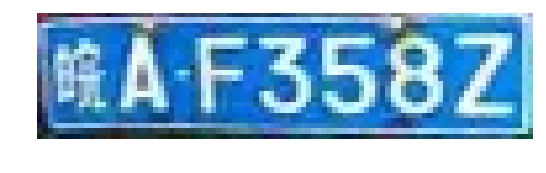

[1, 3, 24, 94]
params loading...
load runs/lprnet_best_2.pdparams success...
皖AF358Z


In [18]:
"""此部分为测试的可视化代码, 后处理可参考"""
import cv2
import matplotlib.pyplot as plt
import numpy as np
import paddle
%matplotlib inline

img_path = 'rec_images/data/皖AF358Z.jpg'
img_data = cv2.imread(img_path)
img_data = img_data[:,:,::-1]  # BGR to RGB
plt.imshow(img_data)
plt.axis('off')
plt.show()

# 数据前处理
img_data = cv2.resize(img_data,(94, 24))
img_data = (img_data - 127.5) / 127.5  # 归一化
img_data = np.transpose(img_data, (2,0,1))  # HWC to CHW
img_data = np.expand_dims(img_data, 0)  # to BCHW
img_tensor = paddle.to_tensor(img_data, dtype='float32')  # shape == [1, 3, 24, 94]
print(img_tensor.shape)

# 加载模型, 预测
CHARS = ['京', '沪', '津', '渝', '冀', '晋', '蒙', '辽', '吉', '黑',
         '苏', '浙', '皖', '闽', '赣', '鲁', '豫', '鄂', '湘', '粤',
         '桂', '琼', '川', '贵', '云', '藏', '陕', '甘', '青', '宁',
         '新',
         '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
         'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K',
         'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V',
         'W', 'X', 'Y', 'Z', 'I', 'O', '-'
         ]
LPRMAXLEN = 18
model = LPRNet(LPRMAXLEN, len(CHARS), dropout_rate=0)
load_pretrained(model, 'runs/lprnet_best_2')
out_data = model(img_tensor)  # out_data.shape == [1, 68, 18]

# 后处理，单张图片数据
def reprocess(pred):
    pred_data = pred[0]
    pred_label = np.argmax(pred_data, axis=0)
    no_repeat_blank_label = []
    pre_c = pred_label[0]
    if pre_c != len(CHARS) - 1:  # 非空白
        no_repeat_blank_label.append(pre_c)
    for c in pred_label:  # dropout repeate label and blank label
        if (pre_c == c) or (c == len(CHARS) - 1):
            if c == len(CHARS) - 1:
                pre_c = c
            continue
        no_repeat_blank_label.append(c)
        pre_c = c
    char_list = [CHARS[i] for i in no_repeat_blank_label]
    return ''.join(char_list)

rep_result = reprocess(out_data)
print(rep_result)  # 皖AF358Z


### TODO

1. 数据集分布不均，这里只用了ccpd2019的蓝牌，可以使用ccpd2020包含绿牌数据

2. 大部分车牌都是“皖”，可以适当添加其他省份的车牌数据

~~3. 车牌裁切没有做矫正，想提高精度，可考虑加上车牌的矫正算法~~

~~4. 本车牌识别网络模型与batch数据耦合，可以尝试解耦后再训练~~

5. 网络模型已经固定了输出序列的长度18，考虑修改为能自定义长度，让模型能适用于更多场景

### 模型导出
#### 导出onnx

这里将模型从动态图导出onnx文件, 直接使用api:paddle.onnx.export

https://www.paddlepaddle.org.cn/documentation/docs/zh/api/paddle/onnx/export_cn.html

In [12]:

model = LPRNet(18, 68, dropout_rate=0)
load_pretrained(model, 'runs/lprnet_best_2')

save_path = 'save_onnx/lprnet' # 需要保存的路径
x_spec = paddle.static.InputSpec([1, 3, 24, 94], 'float32', 'image') 
paddle.onnx.export(model, save_path, input_spec=[x_spec], opset_version=11)

params loading...
load runs/lprnet_best_2.pdparams success...


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/nn/layer/norm.py:712: UserWarning: When training, we now always track global mean and variance.
  "When training, we now always track global mean and variance."
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/nn/layer/norm.py:712: UserWarning: When training, we now always track global mean and variance.
  "When training, we now always track global mean and variance."
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/nn/layer/norm.py:712: UserWarning: When training, we now always track global mean and variance.
  "When training, we now always track global mean and variance."
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/nn/layer/norm.py:712: UserWarning: When training, we now always track global mean and variance.
  "When training, we now always track global mean and variance."
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-pa

2023-07-27 15:03:51 [INFO]	Static PaddlePaddle model saved in save_onnx/paddle_model_static_onnx_temp_dir.
[Paddle2ONNX] Start to parse PaddlePaddle model...
[Paddle2ONNX] Model file path: save_onnx/paddle_model_static_onnx_temp_dir/model.pdmodel
[Paddle2ONNX] Paramters file path: save_onnx/paddle_model_static_onnx_temp_dir/model.pdiparams
[Paddle2ONNX] Start to parsing Paddle model...
[Paddle2ONNX] Use opset_version = 11 for ONNX export.
[Paddle2ONNX] PaddlePaddle model is exported as ONNX format now.
2023-07-27 15:03:52 [INFO]	ONNX model saved in save_onnx/lprnet.onnx.


#### onnx测试
可以在https://netron.app/ 中查看可视化结构

更多参考：https://www.paddlepaddle.org.cn/documentation/docs/zh/guides/advanced/model_to_onnx_cn.html

In [ ]:
!pip install onnx==1.10.2
!pip install onnxruntime==1.9.0

In [14]:
"""检查onnx是否合理，模型的版本、图的结构、节点及其输入和输出"""

import onnx
onnx_model = onnx.load("save_onnx/lprnet.onnx")
check = onnx.checker.check_model(onnx_model)
print('check: ', check)

check:  None


In [15]:
# 导入所需的库
import numpy as np
import onnxruntime
import paddle

# 随机生成输入，用于验证 Paddle 和 ONNX 的推理结果是否一致
x = np.random.random((1, 3, 24, 94)).astype('float32')

# predict by ONNXRuntime
onnx_path = "save_onnx/lprnet.onnx"
ort_sess = onnxruntime.InferenceSession(onnx_path)
ort_inputs = {ort_sess.get_inputs()[0].name: x}
ort_outs = ort_sess.run(None, ort_inputs)

print("Exported model has been predicted by ONNXRuntime!")

# predict by Paddle
model = paddle.jit.load("save_onnx/paddle_model_static_onnx_temp_dir/model")  # 上一步中导出onnx的时候会保存静态图文件到输出目录
model.eval()
paddle_input = paddle.to_tensor(x)
paddle_outs = model(paddle_input)

print("Original model has been predicted by Paddle!")

# compare ONNXRuntime and Paddle results
np.testing.assert_allclose(ort_outs[0], paddle_outs.numpy(), rtol=1.0, atol=1e-05)

print("The difference of results between ONNXRuntime and Paddle looks good!")

Exported model has been predicted by ONNXRuntime!
Original model has been predicted by Paddle!
The difference of results between ONNXRuntime and Paddle looks good!


#### onnx推理

推理与上面相同，只是添加了实际数据的前处理和模型输出的后处理部分

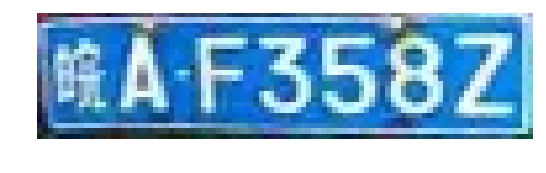

皖AF358Z


In [16]:
import onnxruntime
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# 数据预处理
img_path = 'rec_images/data/皖AF358Z.jpg'
img_data = cv2.imread(img_path)
img_data = img_data[:,:,::-1]  # BGR to RGB
plt.imshow(img_data)
plt.axis('off')
plt.show()

img_data = cv2.resize(img_data,(94, 24))
img_data = (img_data - 127.5) / 127.5  # 归一化
img_data = np.transpose(img_data, (2,0,1))  # HWC to CHW
img_data = np.expand_dims(img_data, 0)  # to BCHW
np_data = np.array(img_data, dtype=np.float32)

# 加载 ONNX 模型生成推理用 sess
onnx_path = "save_onnx/lprnet.onnx"
sess = onnxruntime.InferenceSession(onnx_path)

# 使用 ONNXRuntime 推理
ort_inputs = {sess.get_inputs()[0].name: np_data}
result, = sess.run(None, ort_inputs)

# 推理结果后处理
CHARS = ['京', '沪', '津', '渝', '冀', '晋', '蒙', '辽', '吉', '黑',
         '苏', '浙', '皖', '闽', '赣', '鲁', '豫', '鄂', '湘', '粤',
         '桂', '琼', '川', '贵', '云', '藏', '陕', '甘', '青', '宁',
         '新',
         '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
         'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K',
         'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V',
         'W', 'X', 'Y', 'Z', 'I', 'O', '-'
         ]
def reprocess(pred):
    pred_data = pred[0]
    pred_label = np.argmax(pred_data, axis=0)
    no_repeat_blank_label = []
    pre_c = pred_label[0]
    if pre_c != len(CHARS) - 1:  # 非空白
        no_repeat_blank_label.append(pre_c)
    for c in pred_label:  # dropout repeate label and blank label
        if (pre_c == c) or (c == len(CHARS) - 1):
            if c == len(CHARS) - 1:
                pre_c = c
            continue
        no_repeat_blank_label.append(c)
        pre_c = c
    char_list = [CHARS[i] for i in no_repeat_blank_label]
    return ''.join(char_list)

plate_str = reprocess(result)
print(plate_str)  # 皖AF358Z